# Prepare & Sample Gold Standard Dataset

## Prerequisites

In [1]:
%pip install matplotlib pandas presidio_analyzer presidio_anonymizer nltk faker pandarallel tqdm ipywidgets ipykernel seaborn
%pip install --upgrade nbformat



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import re

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display

from tqdm.notebook import tqdm
from tqdm import tqdm

In [3]:
RANDOM_STATE = 42

## Set up taxonomy df & regex

In [4]:
taxonomy = pd.read_csv("data/input/Additional needs taxonomy.csv", usecols=['Very high level category', 'Category', 'Description (attribute)', 'Value (of data type)'])

columns_rename = {
    'Very high level category': 'top_level_category',
    'Category': 'high_level_category',
    'Description (attribute)': 'category',
    'Value (of data type)': 'values'
}

taxonomy.dropna(inplace=True)
taxonomy.rename(columns=columns_rename, inplace=True)
taxonomy['values'] = taxonomy['values'].str.split("\n")


taxonomy['cat_label'] = taxonomy.apply(lambda row: 'cat_' + str.lower(row['top_level_category'] + '_' + row['high_level_category'] + '_' + row['category']).replace(' ', '_').replace('-', '_'), axis=1)
taxonomy.to_csv("data/output/taxonomy.csv", index=False)

taxonomy = pd.read_csv("data/input/taxonomy-parsed.csv")
taxonomy.sort_values(['top_level_category', 'high_level_category'])

,top_level_category,high_level_category,category,values,cat_label
2,Disability,Adaptation,Requires adapted property,"['Minor adaptations', 'Major adaptation']",cat_disability_adaptation_property
0,Disability,Disability,Sensory,"['Deaf', 'Hearing impairment', 'Visually impai...",cat_disability_disability_sensory
1,Disability,Mobility,Physical disability,"['Wheelchair user', 'Limited mobility (could b...",cat_disability_mobility_physical
3,Safety & Risk,Safety & Risk,Domestic abuse,"['Alleged Perpetrator', 'Survivor']",cat_safety_risk_safety_risk_domestic_abuse
4,Safety & Risk,Safety & Risk,Fire-related risks,"['Arson', 'Fire hazards in the house']",cat_safety_risk_safety_risk_fire_related
5,Safety & Risk,Safety & Risk,Risk of exploitation,"['Financial', 'Sexual', 'Criminal', 'Cuckooing...",cat_safety_risk_safety_risk_exploitation
6,Safety & Risk,Safety & Risk,Serious Youth Violence,"['Gang association', 'Targetted by gang']",cat_safety_risk_safety_risk_youth_violence
7,Safety & Risk,Safety & Risk,Anti-Social Behaviour,"['Perpetrator of harassment', 'Victim of haras...",cat_safety_risk_safety_risk_asb
8,Safety & Risk,Safety & Risk,Children at risk,"['Y, N']",cat_safety_risk_safety_risk_children_at_risk
9,Safety & Risk,Safety & Risk,Criminal activity,['examples needed'],cat_safety_risk_safety_risk_criminal_activity


In [5]:
# category names structure: 'cat' + tl_category + hl_category + category
category_regex_dict = {
    # --- TL: Disability ---
    "cat_disability_disability_sensory": r"\bdeaf\b|\bBSL\b|\bhearing (?:loss|impairment|aid)\b|\bhard of hearing\b|\bblind\w*\b|\bpartially sighted\b|\bvisual impairment\b",
    "cat_disability_mobility_physical": r"\bfrail\w*\b|\bhistory of falls\b|\bpoor mobility\b|\bwalking (?:frame|aid|stick)\b|\bZimmer\b",
    "cat_disability_adaptation_property": r"\bstairlift\b|\bwet room\b|\blevel access\b|\bminor adaptation\w*\b|\bmajor adaptation\w*\b|\bDFG\b|\bOT referral\b",
    
    # --- TL: Safety & Risk ---
    "cat_safety_risk_safety_risk_domestic_abuse": r"\bdomestic abuse\b|\bdomestic violence\b|\bDV\b|\bcoercive control\b|\bIDVA\b|\bDA\b",
    "cat_safety_risk_safety_risk_fire_related": r"\barson\b|\bfire hazard\b|\bfire risk\b|\bfire safety\b|\bno smoke alarm\b|\bcandles?\b",
    "cat_safety_risk_safety_risk_exploitation": r"\bcuckooing\b|\bfinancial (?:exploitation|abuse)\b|\bsexual exploitation\b|\bcriminal exploitation\b|\bmodern slavery\b|\btraffick\w*\b",
    "cat_safety_risk_safety_risk_youth_violence": r"\bgang (?:member|affiliated|involvement)\b|\btargeted by gang\b|\bgang (?:intimidation|threats)\b",
    "cat_safety_risk_safety_risk_asb": r"\bASB\b|\banti-social\b|\bharassment\b|\bhate crime\b|\bnuisance\b",
    "cat_safety_risk_safety_risk_children_at_risk": r"\bchildren? at risk\b|\bchild protection\b|\bsafeguarding (?:child|children)\b|\bSection 47\b|\bS47\b",
    "cat_safety_risk_safety_risk_criminal_activity": r"\bcriminal (?:activity|behaviour|record)\b|\boffend\w*\b|\barrested\b|\bconvicted\b|\bcaution\b",
    "cat_safety_risk_safety_risk_violence": r"\bviolen\w*\b|\bassault\w*\b|\battack\w*\b|\bthreaten\w*\b|\bstabb\w*\b|\bweapon\b",
    "cat_safety_risk_safety_risk_gas_capped": r"\bgas (?:capped|cap)\b|\bgas cap\b",
    
    # --- TL: Vulnerability ---
    # --- HL: Addiction ---
    "cat_vulnerability_addiction_gambling": r"\bgambl\w*\b|\bbetting\b|\bbookmaker\b",
    "cat_vulnerability_addiction_substance": r"\balcohol\w*\b|\bdrinking\b|\bdrunk\w*\b|\bbooze\b|\balcoholic\b|\bdrug\w*\b|\bcocaine\b|\bheroin\b|\bcrack\b|\bcannabis\b|\bmethadone\b|\baddic\w*\b",
    
    # --- HL: Care ---
    "cat_vulnerability_care_experienced": r"\bcare experienced\b|\bcare leaver\b|\baged out of care\b",
    "cat_vulnerability_care_leaver": r"\blooked after\b|\blooked-after\b|\bfoster\w*\b",
    "cat_vulnerability_care_care_setting": r"\bfostered\b|\bfoster care\b|\bfoster placement\b|\bin care\b|\bcare placement\b|\bsocial care placement\b",
    "cat_vulnerability_social_care_involved": r"\bsocial care\b|\bcare package\b|\bcare plan\b|\bcare coordinator\b",
    "cat_vulnerability_caring_responsibility": r"\bformal carer\b|\bregistered carer\b|\bcarer.s allowance\b|\bunpaid carer\b|\bcaring for\b|\blooking after\b",
    
    # --- HL: Communication ---
    "cat_vulnerability_comms_digital_exclusion": r"\bno internet\b|\bno wifi\b|\bdigitally excluded\b|\bno (?:phone|device|computer|laptop|tablet)\b|\bdigital exclusion\b",
    "cat_vulnerability_comms_language_literacy": r"\blow literacy\b|\blanguage barrier\b|\binterpreter\b|\btranslation\b|\bno English\b|\blimited English\b|\bESOL\b",
    
    # --- TL: Service Needs ---
    # --- HL: Communication ---
    "cat_service_need_comms_communication_needs": r"\bBSL\b|\bbraille\b|\bsign language\b|\bhearing loop\b|\binduction loop\b|\blarge print\b|\baudio format\b|\bscreen reader\b|\bcommunication support\b|\bspeech impairment\b|\baugmentative\b|\balternative communication\b|\bAAC\b",

    # --- HL: Financial ---
    "cat_vulnerability_financial_financial_income": r"\bunemployed\b|\blong.term unemploy\w*\b|\bESA\b|\bUniversal Credit\b|\bnot working\b|\bbenefit check\b|\bincorrect benefit\w*\b",
    "cat_vulnerability_financial_cost_of_living": r"\bfood.?bank\b|\bfood parcel\b|\bfuel poverty\b|\bcan.t afford\b|\bheating (?:costs|bills)\b|\bprepay\w* meter\b",
    "cat_vulnerability_financial_client_financial_affairs": r"\bCFAT\b|\bclient financial affairs\b|\bappointeeship\b",
    
    # --- HL: Health ---
    "cat_vulnerability_health_terminally_ill": r"\bterminal\w*\b|\bend of life\b|\bpalliative\b",
    "cat_vulnerability_health_care_setting": r"\bhospice\b|\bnursing home\b|\bcare home\b|\bresidential home\b|\bin hospital\b|\bhospitalised\b|\badmitted to hospital\b|\binpatient\b|\bstaying with (?:family|relatives|friends)\b|\bliving with (?:family|relatives|friends)\b",
    "cat_vulnerability_health_mental_capacity": r"\badvocate\b|\bIMCA\b|\bdeputy\b|\bcourt of protection\b|\bLPA\b|\bpower of attorney\b|\bnext of kin\b",
    "cat_vulnerability_health_neurodiversity": r"\bautis\w*\b|\bASD\b|\bAsperger\w*\b|\bADHD\b|\battention deficit\b|\bdyslexia\b|\blearning disabilit\w*\b",
    "cat_vulnerability_health_cognitive_impairment": r"\bdementia\b|\bAlzheimer\w*\b|\bmemory loss\b|\bcognitive impairment\b",
    "cat_vulnerability_health_reproductive": r"\bpregnant\b|\bpregnancy\b|\bstillbirth\b|\bmiscarriage\b|\bmenopause\b|\bpostnatal\b",
    "cat_vulnerability_health_young_children": r"\bnewborn\b|\binfant\b|\btoddler\b|\bvery young child\b|\bbaby\b",
    "cat_vulnerability_health_respiratory": r"\basthma\b|\binhaler\b|\bCOPD\b|\bchronic obstructive\b|\ballerg\w*\b|\bbreathless\w*\b",
    "cat_vulnerability_health_mental_health": r"\bsuicidal\b|\bself.harm\b|\bdepress\w*\b|\banxiet\w*\b|\bpanic attack\b|\bPTSD\b|\bmental health\b|\blow mood\b",
    "cat_vulnerability_health_social_isolation": r"\blonely\b|\bloneliness\b|\bsocially isolated\b|\bisolat\w*\b|\bno social contact\b",
    "cat_vulnerability_health_poor_health": r"\bfrail\w*\b|\bchronic (?:illness|condition|pain)\b|\bweakened immune\b|\bimmunocompromised\b",
    "cat_vulnerability_health_child_ehcp": r"\bEHCP\b|\beducation health and care\b|\bSEND\b|\bspecial educational needs\b",

    # --- HL: Housing Conditions ---
    "cat_vulnerability_housing_basic_needs": r"\bno gas\b|\bno electric\w*\b|\bno water\b|\bgas (?:cut off|disconnected)\b|\bpower (?:cut|off)\b",
    "cat_vulnerability_housing_disrepair": r"\bdisrepair\b|\bunfit\b|\bunhabitable\b|\brepair\w*\b|\bbroken\b|\bdamaged\b|\bleaking\b",
    "cat_vulnerability_housing_infestation": r"\brat\w*\b|\bmice\b|\bmouse\b|\bvermin\b|\bpest\w*\b|\bbed bug\w*\b|\bcockroach\w*\b|\bflea\w*\b|\bdaddy long.?legs\b|\bsilverfish\b",
    "cat_vulnerability_housing_dangerous_animals": r"\bdangerous dog\b|\bdog attack\b|\bdog bite\b|\baggressive dog\b|\bdangerous (?:pet|animal)\b",
    "cat_vulnerability_housing_self_neglect": r"\bclutter\w*\b|\bhoarding\b|\bhoarder\b|\bself.neglect\b|\bsqualor\b|\bunclean\b",
    "cat_vulnerability_housing_damp_mould": r"\bdamp\b|\bmould\b|\bmold\b|\bcondensation\b|\bleak\w*\b|\bblack mould\b",
    "cat_vulnerability_housing_overcrowding": r"\bovercrowd\w*\b|\bawaiting rehousing\b|\bhome swap\b|\bmutual exchange\b|\bhousing list\b|\bbidding\b",

    # --- HL: Life Events ---
    "cat_vulnerability_life_events_identity": r"\btransgender\b|\btrans (?:woman|man|person)\b|\bnon.binary\b|\bgender dysphoria\b",
    "cat_vulnerability_life_events_refugee": r"\brefugee\b|\basylum seeker\b|\bNRPF\b|\bno recourse\b|\bleave to remain\b",
    "cat_vulnerability_life_events_ex_service": r"\bveteran\b|\bex.service\b|\barmed forces\b|\bformer (?:soldier|military|army|navy|RAF)\b",
    "cat_vulnerability_life_events_bereavement": r"\bbereavement\b|\bbereaved\b|\bgrief\b|\bgrieving\b|\bpassed away\b|\bdeath of\b",
    "cat_vulnerability_life_events_left_institution": r"\breleased from prison\b|\bon (?:licence|probation)\b|\bprobation\b|\bdischarged from hospital\b|\bleft (?:refuge|supported housing)\b",
    "cat_vulnerability_life_events_rehoused_decant": r"\btemporary accommodation\b|\btemp accom\b|\bdecant\w*\b|\bB&B\b|\bhostel\b",
    "cat_vulnerability_life_events_in_prison": r"\bcurrently in prison\b|\bin (?:custody|jail|prison)\b|\bremanded\b|\bHMP\b",
    "cat_vulnerability_life_events_homelessness": r"\bstreet homeless\b|\bsleeping rough\b|\brough sleep\w*\b|\bno fixed abode\b|\bNFA\b|\bsofa surf\w*\b",
    
    # --- HL: Mobility ---
    "cat_vulnerability_mobility_mobility": r"\bwheelchair\b|\bphysical disabilit\w*\b|\bphysically disabled\b|\bamputee\b|\bparalys\w*\b",
    "cat_vulnerability_mobility_temporary_mobility": r"\bcrutch\w*\b|\bbroken (?:leg|ankle|hip|arm)\b|\bpost.op\b|\brecovering from (?:surgery|operation)\b",

    # --- Safety & Risk ---
    "cat_vulnerability_safety_home_unsuitable": r"\bhome unsuitable\b|\bmedically unsuitable\b|\bproperty unsuitable\b",
}

## Import df

In [6]:
df = pd.read_csv('./data/input/regex_results.csv', usecols=['note_id', 'note_content', 'note_category'])

# Add the note category as a prefix to the note content
df['note_content'] = "[Category: " + df['note_category'].fillna('Unknown').astype(str) + "] " + df['note_content'].astype(str)

## Find acronyms


In [7]:
import nltk
from collections import Counter

# Download the english dictionary (only needs to be run once)
nltk.download('words')
from nltk.corpus import words

# Load the standard English vocabulary into a fast-lookup set
english_vocab = set(word.lower() for word in words.words())

# 1. Combine all notes into one giant string, lowercase it
all_text = " ".join(df['note_content'].dropna().str.lower())

# 2. Extract all 2-to-4 letter words
short_words = re.findall(r'\b[a-z]{2,4}\b', all_text)

# 3. DICTIONARY SUBTRACTION: Only keep words NOT in the English dictionary
# (We also filter out 'url' since you already caught it!)
jargon_only = [word for word in short_words if word not in english_vocab]

# 4. Look at the top 100 most common jargon words
top_jargon = Counter(jargon_only).most_common(100)

top_jargon

[nltk_data] Downloading package words to /Users/arawat/nltk_data...
[nltk_data]   Package words is already up-to-date!


[('tnt', 170055),
 ('has', 164217),
 ('lh', 61291),
 ('uk', 60554),
 ('gov', 50431),
 ('ms', 40465),
 ('asb', 39644),
 ('cb', 31495),
 ('hb', 30219),
 ('paid', 23169),
 ('sc', 18371),
 ('keys', 15539),
 ('rcc', 15068),
 ('cc', 14699),
 ('tel', 14392),
 ('hsc', 14003),
 ('dd', 13644),
 ('says', 13322),
 ('ange', 13285),
 ('doua', 12804),
 ('com', 11892),
 ('pls', 11040),
 ('rtb', 9784),
 ('auth', 9575),
 ('eo', 9277),
 ('cleo', 7836),
 ('nosp', 7388),
 ('co', 6542),
 ('bacs', 5982),
 ('wba', 5963),
 ('rec', 5758),
 ('info', 5742),
 ('nho', 5742),
 ('uhw', 5514),
 ('olu', 5283),
 ('fobs', 5214),
 ('docs', 5059),
 ('mpa', 4889),
 ('mw', 4700),
 ('ali', 4694),
 ('tnts', 4544),
 ('hh', 4525),
 ('appt', 4238),
 ('app', 4173),
 ('ntq', 4123),
 ('itv', 3986),
 ('ncst', 3928),
 ('uc', 3693),
 ('acc', 3626),
 ('ve', 3537),
 ('gge', 3493),
 ('emre', 3336),
 ('mmh', 3196),
 ('recd', 3046),
 ('etc', 3038),
 ('acct', 3018),
 ('feb', 2871),
 ('sms', 2795),
 ('tmo', 2775),
 ('org', 2751),
 ('uht', 274

## Replace acronyms

In [8]:
normalization_dict = {
    # Hackney terms
    r'\bhsc\b': 'hackney service centre',
    r'\bmmh\b': 'Manage My Home',
    r'\blbh\b': 'London Borough of Hackney',
    r'\brcc\b': 'repairs contact centre',
    r'\buh\b': 'universal housing',
    # r'\buhw\b': 'universal housing ?',
    # r'\buht\b': 'universal housing ?',
    # r'\bncst\b': '??',

    # Housing terms
    r'\btnt\b': 'tenant',
    r'\btnts\b': 'tenants',
    r'\btmo\b': 'tenant management organisation',
    # r'\bdlo\b': 'direct labour organisation ??',
    r'\bnho\b': 'neighbourhood housing officer',
    r'\bahm\b': 'area housing manager',
    # r'\beo\b': 'estate officer',
    r'\bhb\b': 'housing benefit',
    r'\bnosp\b': 'notice of seeking possession',
    r'\bntq\b': 'notice to quit',
    r'\brtb\b': 'right to buy',
    r'\buc\b': 'universal credit',
    r'\basb\b': 'anti-social behaviour',
    # r'\bmpa\b': 'multiple ??',
    # r'\bctax\b': 'council tax',
    r'\bdv\b': 'domestic violence',

    # General terms
    r'\btel\b': 'telephone',
    r'\bdocs\b': 'documents',
    r'\bappt\b': 'appointment',
    r'\bacct\b': 'account',
    r'\bbacs\b': 'bank transfer',
    r'\binfo\b': 'information',
    r'\borg\b': 'organisation',
    r'\bsms\b': 'text message',
    r'\bmsg\b': 'message',
    r'\bcctv\b': 'camera',
    r'\bgp\b': 'general practitioner',
    r'\bpls\b': 'please',
    r'\brecd\b': 'received',
    r'\basap\b': 'as soon as possible',
    r'\bpls\b': 'please',
    r'\bcert\b': 'certificate',
    # r'\bo/s\b': 'outstanding',
    # r'\btc\b': 'telephone call',
    # r'\blm\b': 'left message',
    # r'\bvm\b': 'voicemail',
}

In [9]:
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)

compiled_normalizations = [(re.compile(p, re.IGNORECASE), r) for p, r in normalization_dict.items()]

def normalize(text):
    if pd.isna(text):
        return text
    for pattern, replacement in compiled_normalizations:
        text = pattern.sub(replacement, text)
    return text

df['note_content'] = df['note_content'].parallel_apply(normalize)


INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


## Find categories with regex

In [ ]:
# Compile regex and paraellelize to make more efficient
compiled = {label: re.compile(pattern, re.IGNORECASE) for label, pattern in category_regex_dict.items()} 
pandarallel.initialize(progress_bar=False)

for label, pattern in tqdm(compiled.items(), desc="Flagging categories"):
    df[label] = df['note_content'].parallel_apply(lambda x: bool(pattern.search(x)) if pd.notna(x) else False)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


Flagging categories:  89%|████████▉ | 49/55 [01:30<00:10,  1.68s/it]

## Save & Export

In [ ]:
# Save to CSV
df.to_csv("data/output/regex_results_flagged.csv", index=False)

## Import

In [ ]:
df = pd.read_csv("data/output/regex_results_flagged.csv")
df

,note_id,note_content,note_category,cat_disability_disability_sensory,cat_disability_mobility_physical,cat_disability_adaptation_property,cat_safety_risk_safety_risk_domestic_abuse,cat_safety_risk_safety_risk_fire_related,cat_safety_risk_safety_risk_exploitation,cat_safety_risk_safety_risk_youth_violence,...,cat_vulnerability_life_events_refugee,cat_vulnerability_life_events_ex_service,cat_vulnerability_life_events_bereavement,cat_vulnerability_life_events_left_institution,cat_vulnerability_life_events_rehoused_decant,cat_vulnerability_life_events_in_prison,cat_vulnerability_life_events_homelessness,cat_vulnerability_mobility_mobility,cat_vulnerability_mobility_temporary_mobility,cat_vulnerability_safety_home_unsuitable
0,3c0b312c-dbac-8b9e-7aea-f498c148d6f0,[Category: Rents] [Process: 1614025] no contact,Rents,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4471b4f3-2c40-de3d-9f71-4a94bf276ed5,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,47794849-32e7-3f12-1e2d-1d2f9dfd0adb,"[Category: Tenure management] Void, right to b...",Tenure management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,677f5a9c-585d-78e7-4560-f5f43b4a449b,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,79c829fd-733b-5b63-de88-36e35ed3c2e3,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731177,70ddb3a9-3ce6-df29-820e-c82b7297ffa7,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
731178,a0db9fde-8c0e-218c-37df-e88d75137c4a,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
731179,a45124ee-a28f-201c-bee3-6ad6ff65b5b4,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
731180,de00e635-2184-9401-fa80-fd7d43e80624,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Analyse class imbalance (initial)

In [ ]:
def analyse_class_imbalance(raw_df, taxonomy_df, log_scale=True):
    category_counts = raw_df.drop(columns=['note_id', 'note_content', 'note_category']).sum(axis=0).sort_values(ascending=False)
    df = taxonomy_df.join(category_counts.rename('frequency'), on='cat_label').sort_values('frequency', ascending=False)

    # Bar chart
    plt.figure(figsize=(13, 13), dpi=80)
    sns.barplot(data=df, y='cat_label', x='frequency', hue='high_level_category', dodge=False)
    if log_scale:
       plt.xscale('log')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.title(f"Count of Notes by Category (n={len(raw_df)}) {'(log scale)' if log_scale else ''}")
    plt.tight_layout()
    plt.show()

    # Histogram
    plt.figure(dpi=80)
    sns.histplot(data=df, x='frequency', log_scale=log_scale, bins=10)
    plt.xlabel(f"Frequency {'(log scale)' if log_scale else ''}")
    plt.title(f"Distribution of Category Frequencies (n={len(df)})")
    plt.tight_layout()
    plt.show()

    # IRLbl per label
    max_freq = df['frequency'].max()
    irlbl = max_freq / df['frequency']
    irlbl_df = pd.DataFrame({'label': df['cat_label'].values, 'IRLbl': irlbl.values})
    display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))

    # Summary stats
    summary = pd.DataFrame({
        'Metric': ['MeanIR', 'MaxIR', 'CVIR'],
        'Value': [irlbl.mean(), irlbl.max(), irlbl.std() / irlbl.mean()]
    }).style.format({'Value': '{:.2f}'})
    display(summary)

    hl_freqs = df.groupby('high_level_category').agg({'frequency': 'sum'}).sort_values('frequency')
    hl_freqs.plot.barh(title="high level category counts")
    plt.show()

    # Co-occurence heatmap
    df_cats = raw_df[[cat for cat in raw_df.columns if cat.startswith("cat_")]].astype(int) # Convert Booleans to 1s and 0s
    co_matrix = df_cats.T.dot(df_cats)# Calculate co-occurrence using dot product

    # Force diagonals to be 0s so they don't blow out scale
    co_matrix_arr = co_matrix.to_numpy(copy=True)
    np.fill_diagonal(co_matrix_arr, 0) 
    co_matrix = pd.DataFrame(co_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

    # Heatmap
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        co_matrix, 
        cmap="Blues", 
        annot=False, 
        linewidths=0.5, 
        linecolor='lightgrey',
        cbar_kws={'label': 'Number of Co-occurring Notes'}
    )

    plt.title("Label Co-occurrence", fontsize=18, pad=20)
    plt.xlabel("ANs Categories", fontsize=14)
    plt.ylabel("ANs Categories", fontsize=14)


    plt.tight_layout()
    plt.show()

    # Plotly treemap
    fig = px.treemap(
        df[['high_level_category', 'category', 'frequency']],
        path=['high_level_category', 'category'],
        values='frequency',
        color='high_level_category',
        title=f'Additional Needs Category Frequency (n={len(raw_df)})',
        hover_data={'frequency': ':,'}
    )
    fig.update_traces(
        textinfo='label+value',
        hovertemplate='<b>%{label}</b><br>Count: %{value:,}<extra></extra>'
    )
    fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
    fig.show()

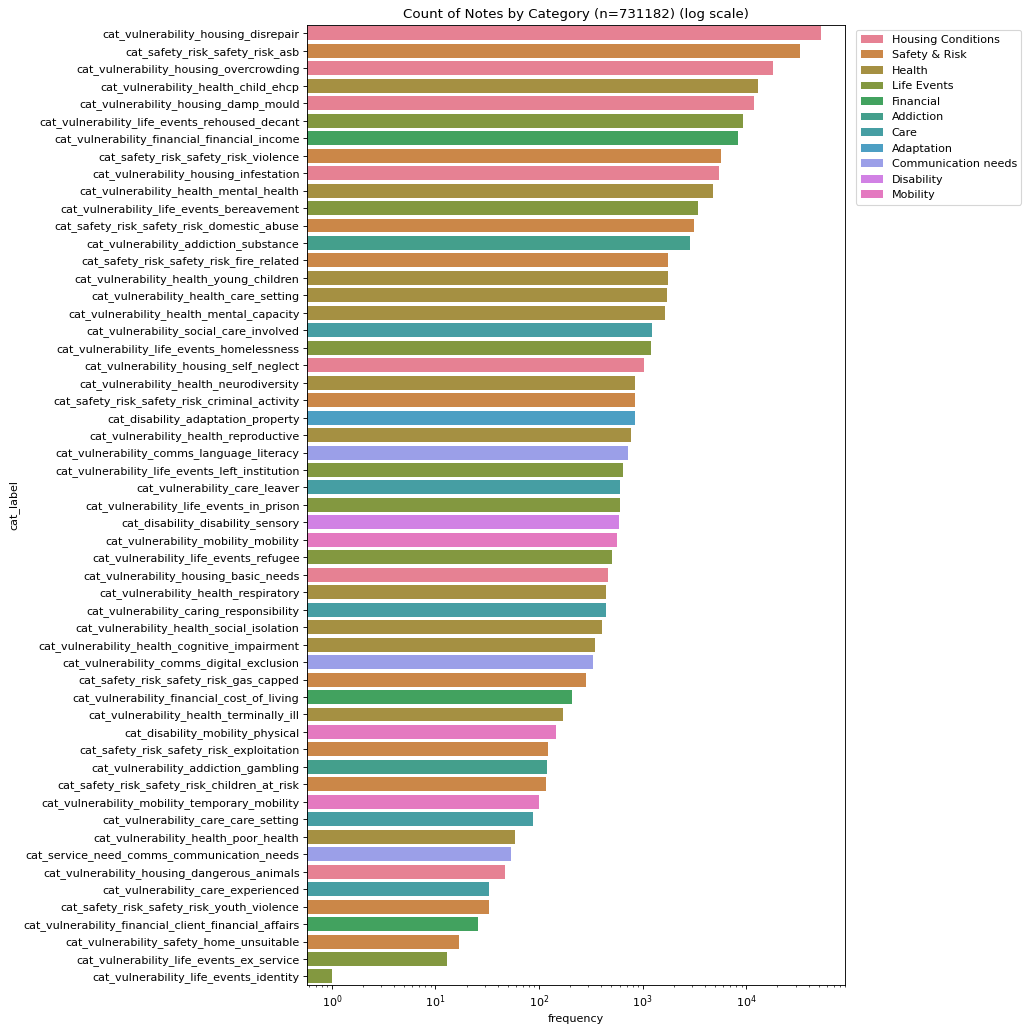

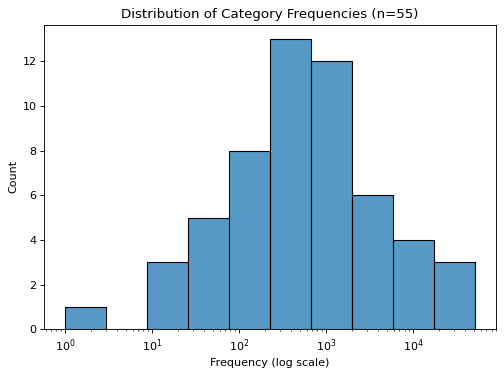

,label,IRLbl
0,cat_vulnerability_housing_disrepair,1.000000
1,cat_safety_risk_safety_risk_asb,1.587892
2,cat_vulnerability_housing_overcrowding,2.902442
3,cat_vulnerability_health_child_ehcp,4.024779
4,cat_vulnerability_housing_damp_mould,4.361044
5,cat_vulnerability_life_events_rehoused_decant,5.649995
6,cat_vulnerability_financial_financial_income,6.306004
7,cat_safety_risk_safety_risk_violence,9.174180
8,cat_vulnerability_housing_infestation,9.626726
9,cat_vulnerability_health_mental_health,10.962482


,Metric,Value
0,MeanIR,1329.08
1,MaxIR,52302.00
2,CVIR,5.30


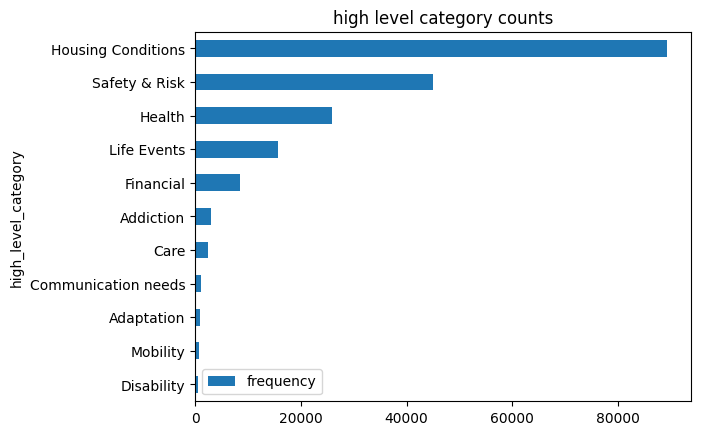

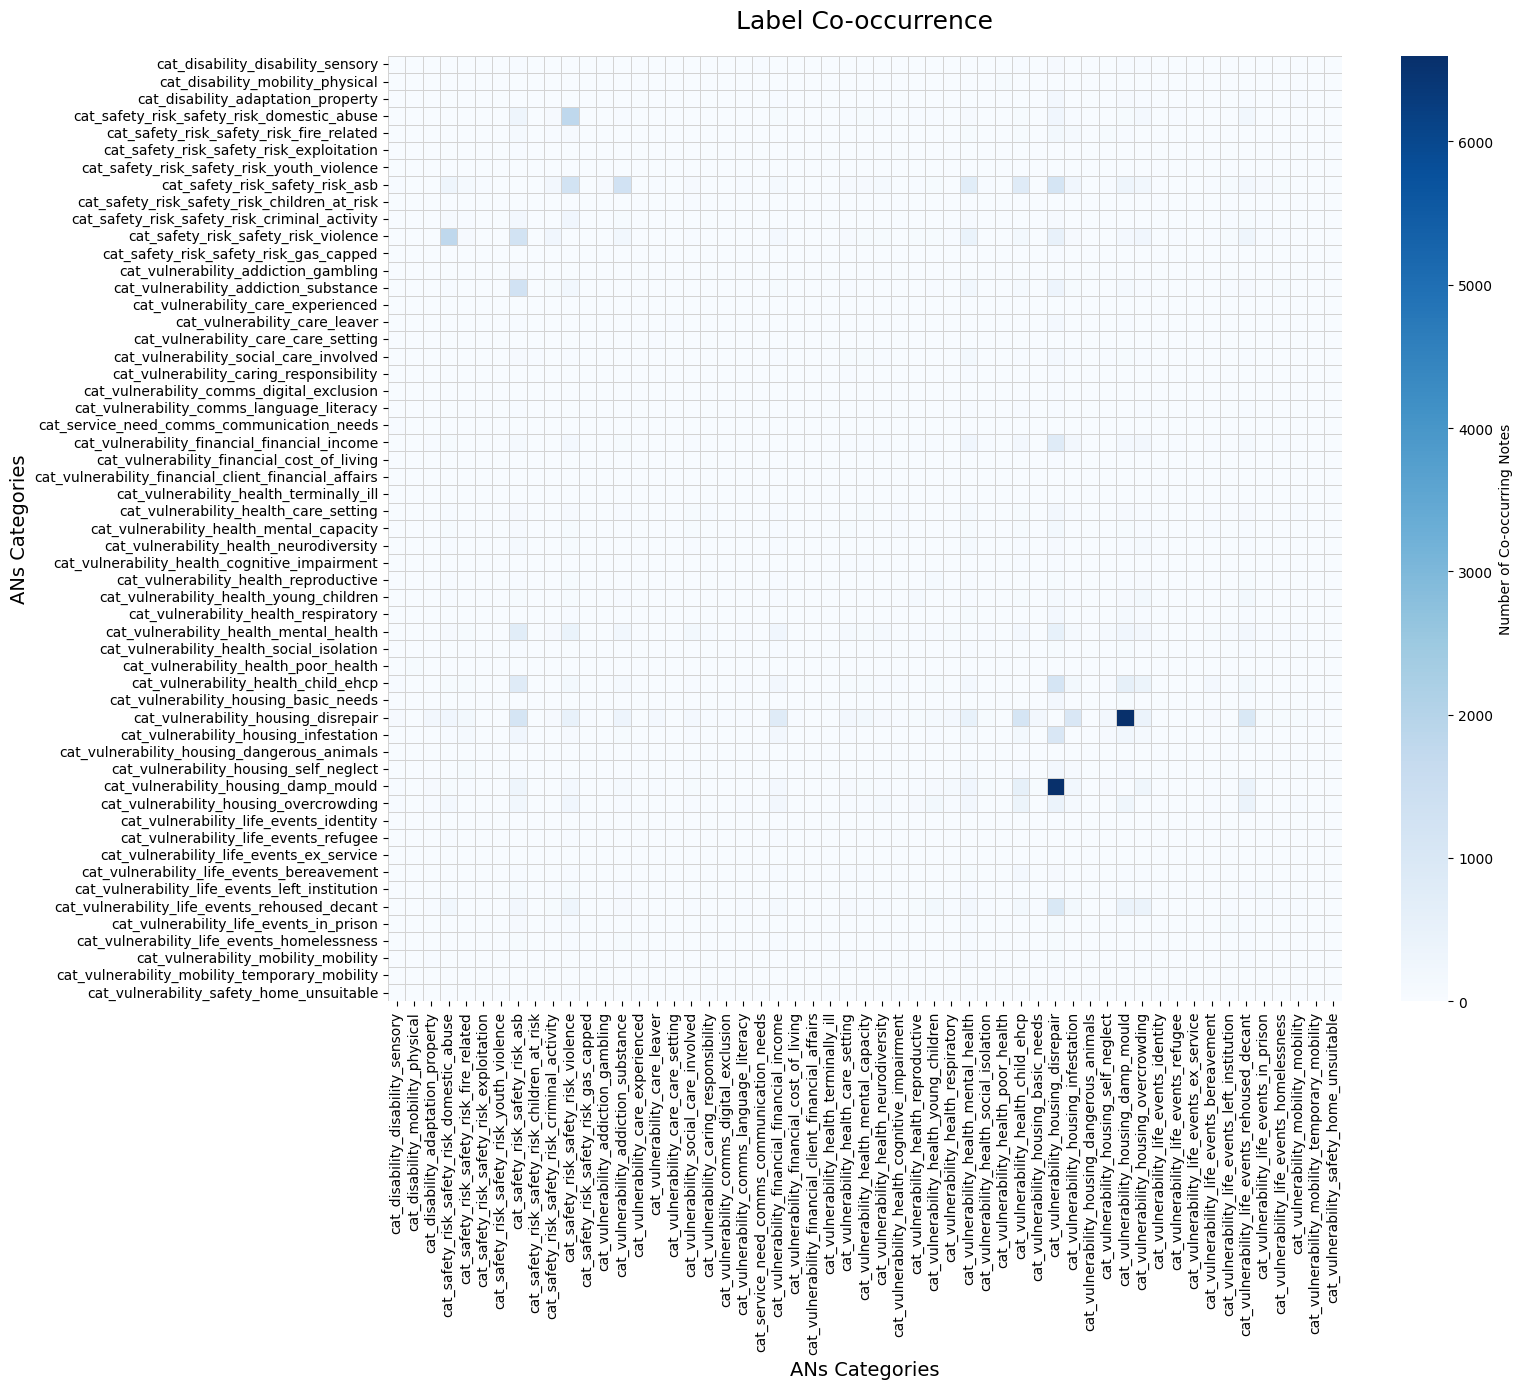

In [ ]:
analyse_class_imbalance(df, taxonomy)

## Combine & drop rare categories

In [ ]:
# Constuct v2 df & category_regex_dict
df_v2 = df.copy()
category_regex_dict_v2 = category_regex_dict.copy()

combined_categories = {
    'cat_vulnerability_care': [
        'cat_vulnerability_care_experienced',
        'cat_vulnerability_care_care_setting',
        'cat_vulnerability_care_leaver',
    ],
    'cat_vulnerability_financial': [
        'cat_vulnerability_financial_financial_income',
        'cat_vulnerability_financial_cost_of_living',
        'cat_vulnerability_financial_client_financial_affairs',
    ],
    'cat_vulnerability_health_poor_health': [
        'cat_vulnerability_health_poor_health',
        'cat_vulnerability_health_terminally_ill',
    ],
    'cat_vulnerability_mobility': [
        'cat_vulnerability_mobility_mobility',
        'cat_vulnerability_mobility_temporary_mobility',
        'cat_disability_mobility_physical',
    ],
    'cat_service_need_comms': [
        'cat_service_need_comms_communication_needs',
        'cat_vulnerability_comms_language_literacy',
        'cat_vulnerability_comms_digital_exclusion',
    ],
    'cat_safety_risk_safety_risk_violence': [
        'cat_safety_risk_safety_risk_violence',
        'cat_safety_risk_safety_risk_youth_violence',
    ],
}

for new_label, source_labels in combined_categories.items():
    # Combine df columns
    df_v2[new_label] = df_v2[source_labels].any(axis=1)
    # Combine regexes (skip sources that don't exist in regex dict)
    patterns = [category_regex_dict_v2[l] for l in source_labels if l in category_regex_dict_v2]
    if patterns:
        category_regex_dict_v2[new_label] = '|'.join(patterns)

# Drop source columns that were combined (but only if the new column names aren't the same as the old ones)
combined_category_sources = [l for sources in combined_categories.values() for l in sources]
dropped_categories = [
    # --- Not prevalent enough ---
    'cat_vulnerability_life_events_identity', # Only one hit. Should drop.
    'cat_vulnerability_life_events_ex_service', # 13 hits
    'cat_vulnerability_safety_home_unsuitable', # 17 hits
    'cat_vulnerability_housing_dangerous_animals', # 47 hits
    # Combined sources (auto-derived, excluding in-place updates)
    *[l for l in combined_category_sources if l not in combined_categories.keys()]
]

df_v2.drop(columns=dropped_categories, inplace=True)
for l in dropped_categories:
    category_regex_dict_v2.pop(l, None)

In [ ]:
del df # memory saving

In [ ]:
taxonomy_v2 = pd.read_csv("data/input/taxonomy-parsed-v2.csv")

len(taxonomy_v2) == len(taxonomy) - len(dropped_categories) + 4

True

## Analyse class imbalance (combined/dropped categories)

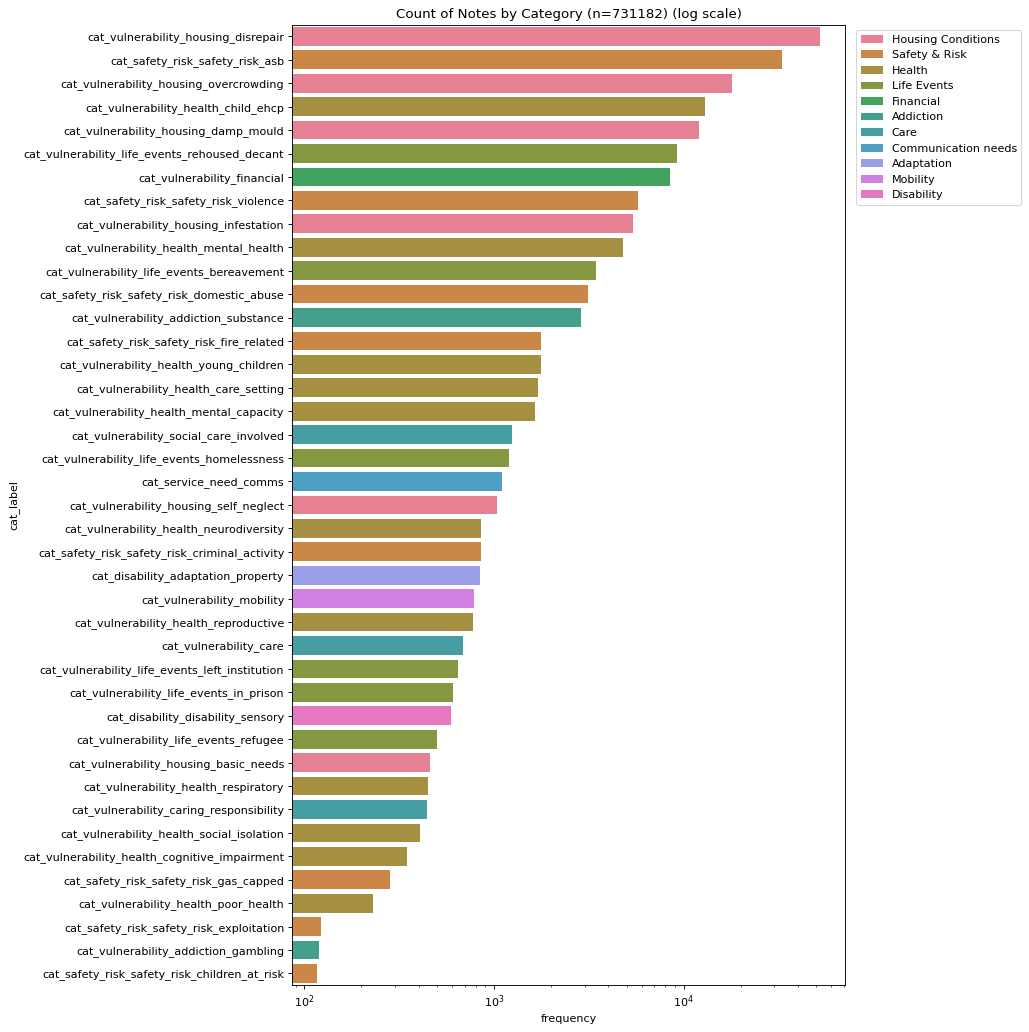

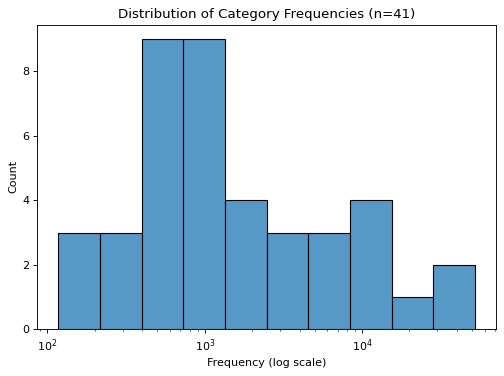

,label,IRLbl
0,cat_vulnerability_housing_disrepair,1.000000
1,cat_safety_risk_safety_risk_asb,1.587892
2,cat_vulnerability_housing_overcrowding,2.902442
3,cat_vulnerability_health_child_ehcp,4.024779
4,cat_vulnerability_housing_damp_mould,4.361044
5,cat_vulnerability_life_events_rehoused_decant,5.649995
6,cat_vulnerability_financial,6.140174
7,cat_safety_risk_safety_risk_violence,9.142108
8,cat_vulnerability_housing_infestation,9.626726
9,cat_vulnerability_health_mental_health,10.962482


,Metric,Value
0,MeanIR,85.68
1,MaxIR,447.03
2,CVIR,1.31


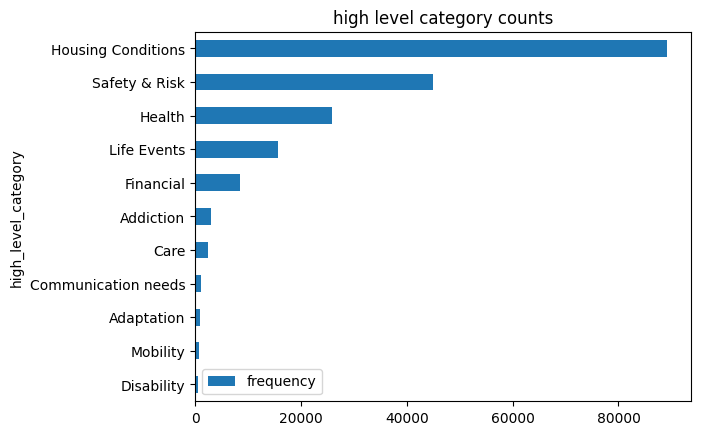

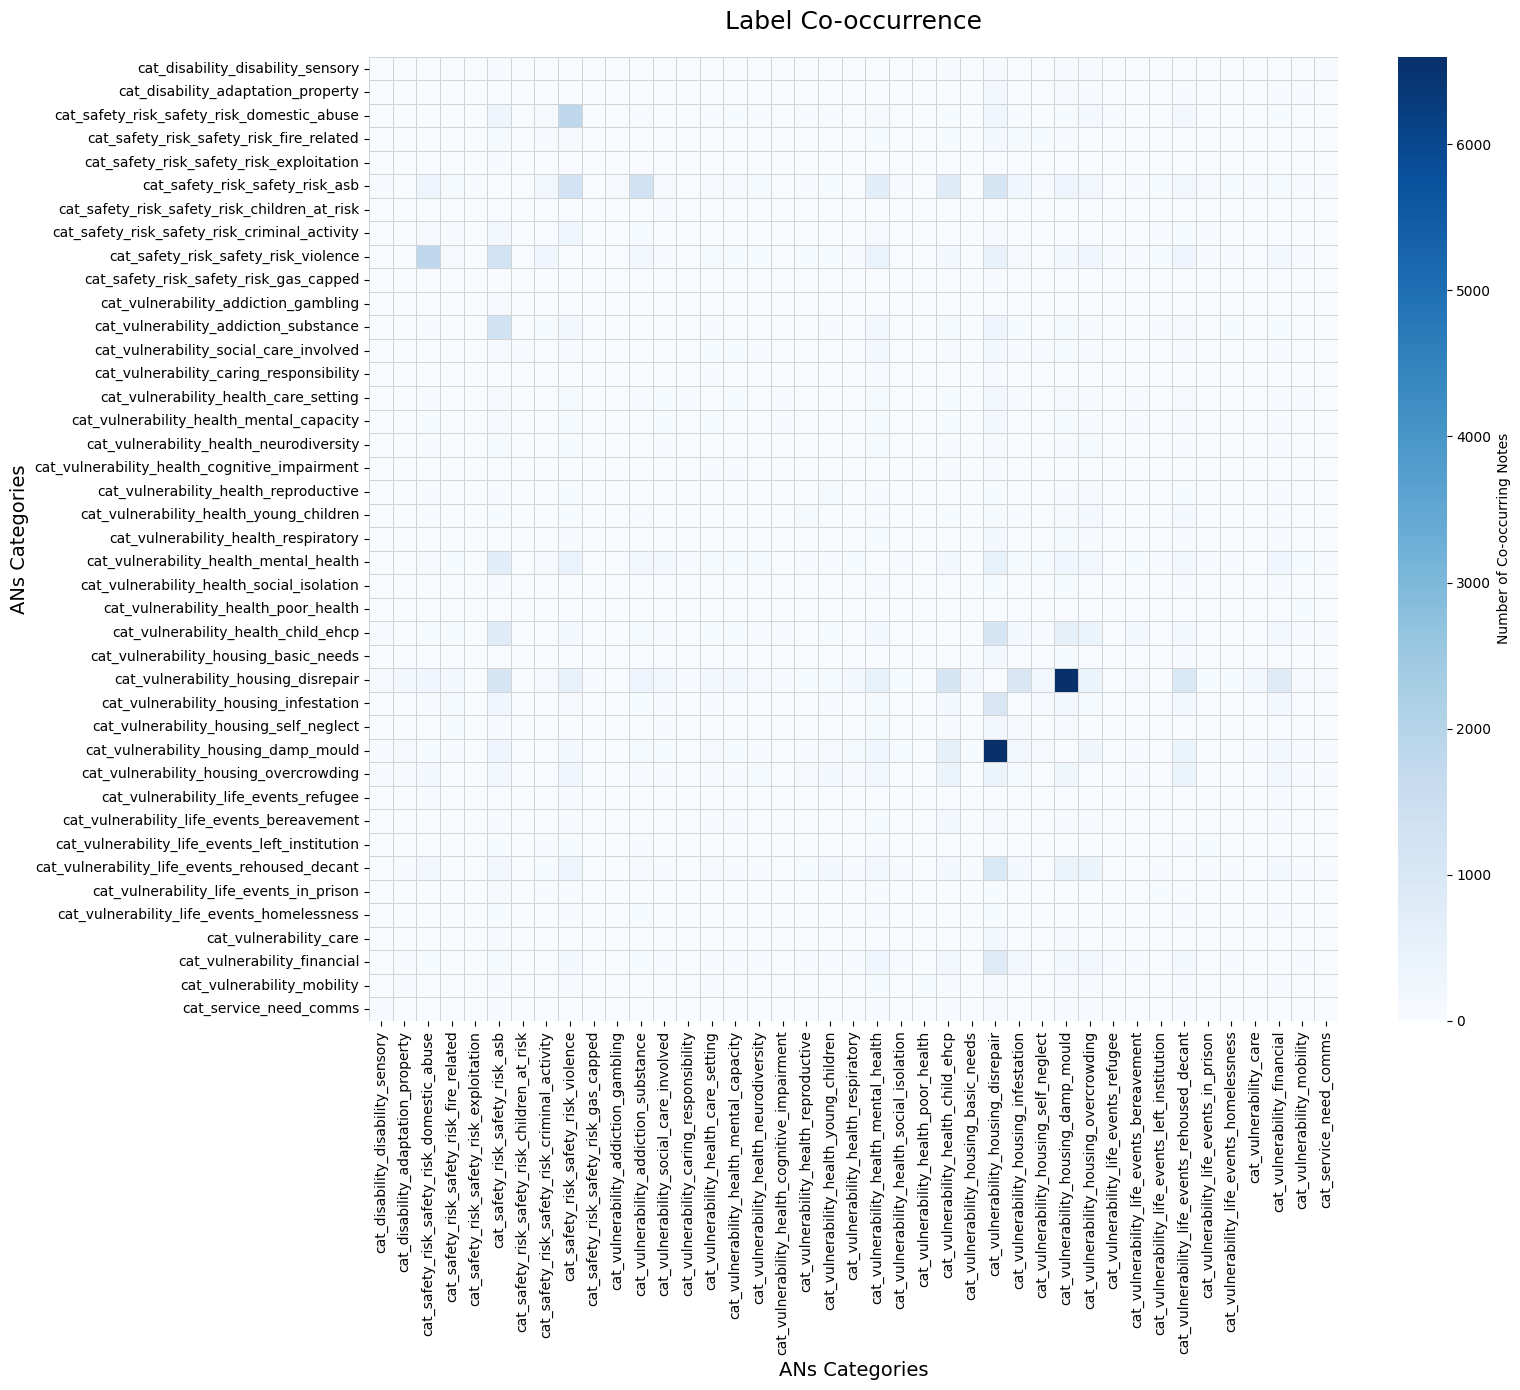

In [ ]:
analyse_class_imbalance(df_v2, taxonomy_v2)

## Sample data (n=2000)
ML-RUS (Random Undersampling) - Iterative Minority-First Selection

In [ ]:
TARGET_TOTAL = 1500
TARGET_PER_CAT = 45 # 45 * 40 = 1800. Leaves ~ 200 unflagged 
sampled_data = []
sampled_ids = set()

# Order by least frequent first
df_v2.drop_duplicates(inplace=True)
category_counts = df_v2.drop(columns=['note_id', 'note_content', 'note_category']).sum(axis=0).sort_values(ascending=True)


# Iterative Sampling (Smallest to Largest)
for cat, count in category_counts.items():
    # Find records for category that haven't been picked yet
    available_pool = df_v2[(df_v2[cat] == True) & (~df_v2['note_id'].isin(sampled_ids))]
    
    # Sample all, up to 45
    n_to_sample = min(len(available_pool), TARGET_PER_CAT)
    print(f"{cat}: {n_to_sample}/{len(available_pool)} sampled. Already sampled: {count- len(available_pool)}")
    
    if n_to_sample > 0:
        cat_sample = available_pool.sample(n=n_to_sample, random_state=RANDOM_STATE)
        sampled_data.append(cat_sample)
        sampled_ids.update(cat_sample['note_id'].tolist())

# Get the 'unflagged' records - zero category matches, and sample.
df_v2['unflagged'] = ~df_v2.drop(columns=['note_id', 'note_content', 'note_category']).any(axis=1)
available_pool = df_v2[(df_v2['unflagged'] == True) & (~df_v2['note_id'].isin(sampled_ids))]
n_to_sample = min(len(available_pool), TARGET_TOTAL - len(sampled_ids)) # Fill up remaining space with unflagged records
print(f"unflagged: {n_to_sample}/{len(available_pool)} sampled")
if n_to_sample > 0:
    cat_sample = available_pool.sample(n=n_to_sample, random_state=RANDOM_STATE)
    sampled_data.append(cat_sample)
    sampled_ids.update(cat_sample['note_id'].tolist())


# Combine & shuffle
final_sample = pd.concat(sampled_data).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
final_sample

cat_safety_risk_safety_risk_children_at_risk: 35/116 sampled. Already sampled: 0
cat_safety_risk_safety_risk_exploitation: 35/119 sampled. Already sampled: 1
cat_vulnerability_addiction_gambling: 35/120 sampled. Already sampled: 0
cat_vulnerability_health_poor_health: 35/229 sampled. Already sampled: 0
cat_safety_risk_safety_risk_gas_capped: 35/284 sampled. Already sampled: 0
cat_vulnerability_health_cognitive_impairment: 35/346 sampled. Already sampled: 1
cat_vulnerability_health_social_isolation: 35/402 sampled. Already sampled: 0
cat_vulnerability_health_respiratory: 35/437 sampled. Already sampled: 2
cat_vulnerability_caring_responsibility: 35/438 sampled. Already sampled: 4
cat_vulnerability_housing_basic_needs: 35/439 sampled. Already sampled: 4
cat_vulnerability_life_events_refugee: 35/499 sampled. Already sampled: 3
cat_disability_disability_sensory: 35/587 sampled. Already sampled: 1
cat_vulnerability_life_events_in_prison: 35/599 sampled. Already sampled: 3
cat_vulnerability_

,note_id,note_content,note_category,cat_disability_disability_sensory,cat_disability_adaptation_property,cat_safety_risk_safety_risk_domestic_abuse,cat_safety_risk_safety_risk_fire_related,cat_safety_risk_safety_risk_exploitation,cat_safety_risk_safety_risk_asb,cat_safety_risk_safety_risk_children_at_risk,...,cat_vulnerability_life_events_bereavement,cat_vulnerability_life_events_left_institution,cat_vulnerability_life_events_rehoused_decant,cat_vulnerability_life_events_in_prison,cat_vulnerability_life_events_homelessness,cat_vulnerability_care,cat_vulnerability_financial,cat_vulnerability_mobility,cat_service_need_comms,unflagged
0,4225661c-e92f-102d-853a-50e621ea5df8,[Category: Tenure management] Applicant attend...,Tenure management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,NaN
1,2a0cd115-cb4f-45a9-9d9f-946e01ceb68c,[Category: estateManagement] Incoming Call - a...,estateManagement,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,NaN
2,26fc5b32-489c-c5b4-19b6-7fb76c8e0565,[Category: Tenancy Management] Email sent to a...,Tenancy Management,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,NaN
3,1cb54851-891c-4171-b88a-a5c6877c37de,[Category: estateManagement] Redecorations ema...,estateManagement,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,NaN
4,14e45fd5-a617-7c2d-c72a-88a669251074,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,93f945a0-a050-472a-b822-1dc8a005e86a,[Category: serviceCharge] Major Work The daugh...,serviceCharge,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,NaN
1496,c3e9936d-337b-27eb-ec37-6ccf0aad612f,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,NaN
1497,99236980-85a3-3a64-0f3e-63ad6fbc7efe,[Category: Tenancy Management] 26/05/20: Telep...,Tenancy Management,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,False,False,NaN
1498,ed7f9f80-b797-4d92-9281-726906f12f15,[Category: estateManagement] email from tenant...,estateManagement,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
del df_v2 # Memory saving

## Analyse class imbalance (gold standard sample)

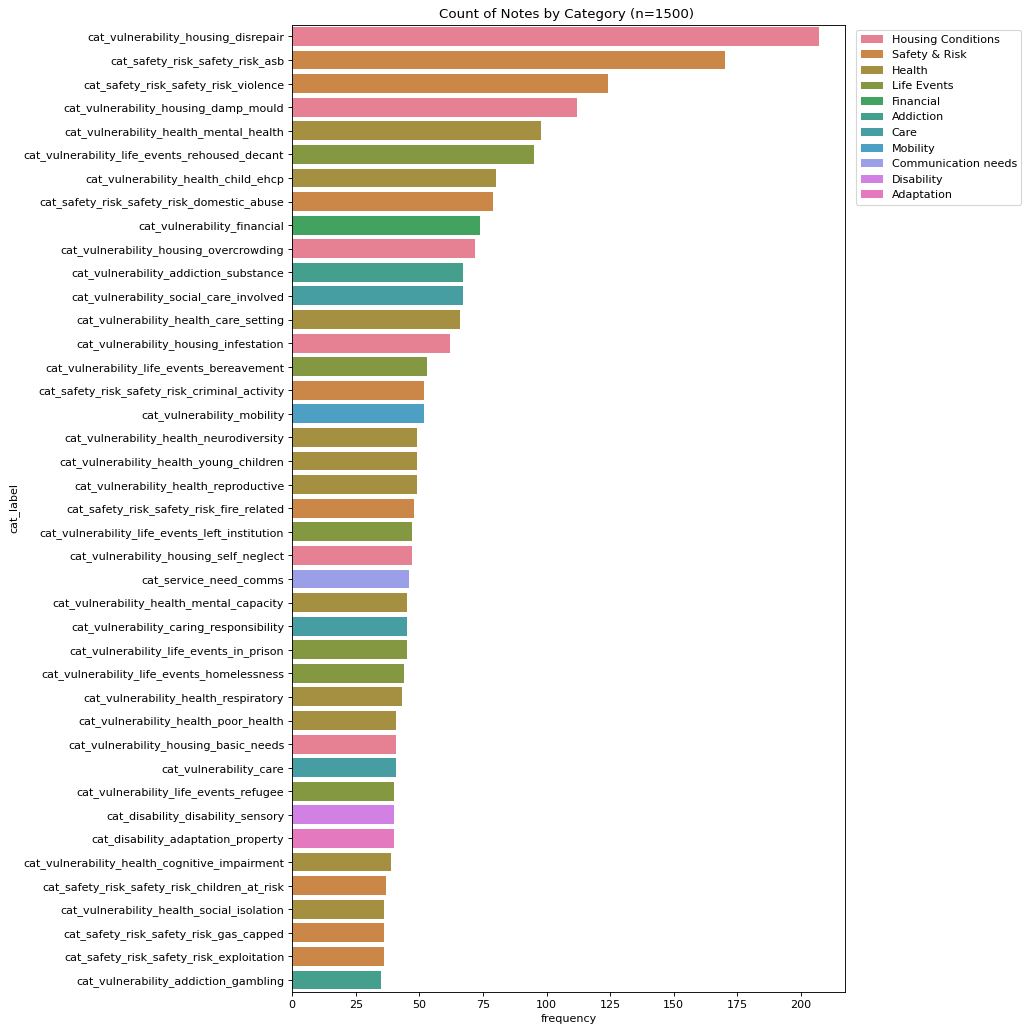

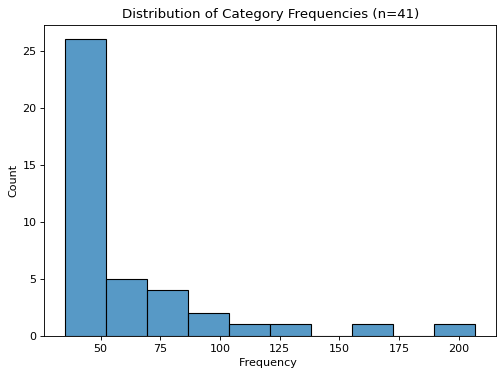

,label,IRLbl
0,cat_vulnerability_housing_disrepair,1.000000
1,cat_safety_risk_safety_risk_asb,1.217647
2,cat_safety_risk_safety_risk_violence,1.669355
3,cat_vulnerability_housing_damp_mould,1.848214
4,cat_vulnerability_health_mental_health,2.112245
5,cat_vulnerability_life_events_rehoused_decant,2.178947
6,cat_vulnerability_health_child_ehcp,2.587500
7,cat_safety_risk_safety_risk_domestic_abuse,2.620253
8,cat_vulnerability_financial,2.797297
9,cat_vulnerability_housing_overcrowding,2.875000


,Metric,Value
0,MeanIR,3.99
1,MaxIR,5.91
2,CVIR,0.33


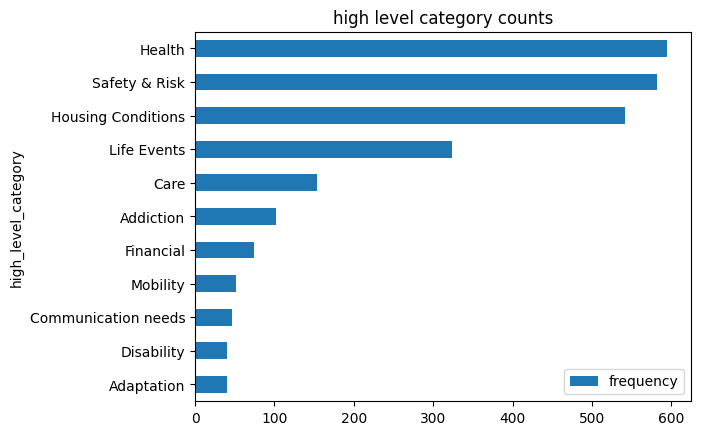

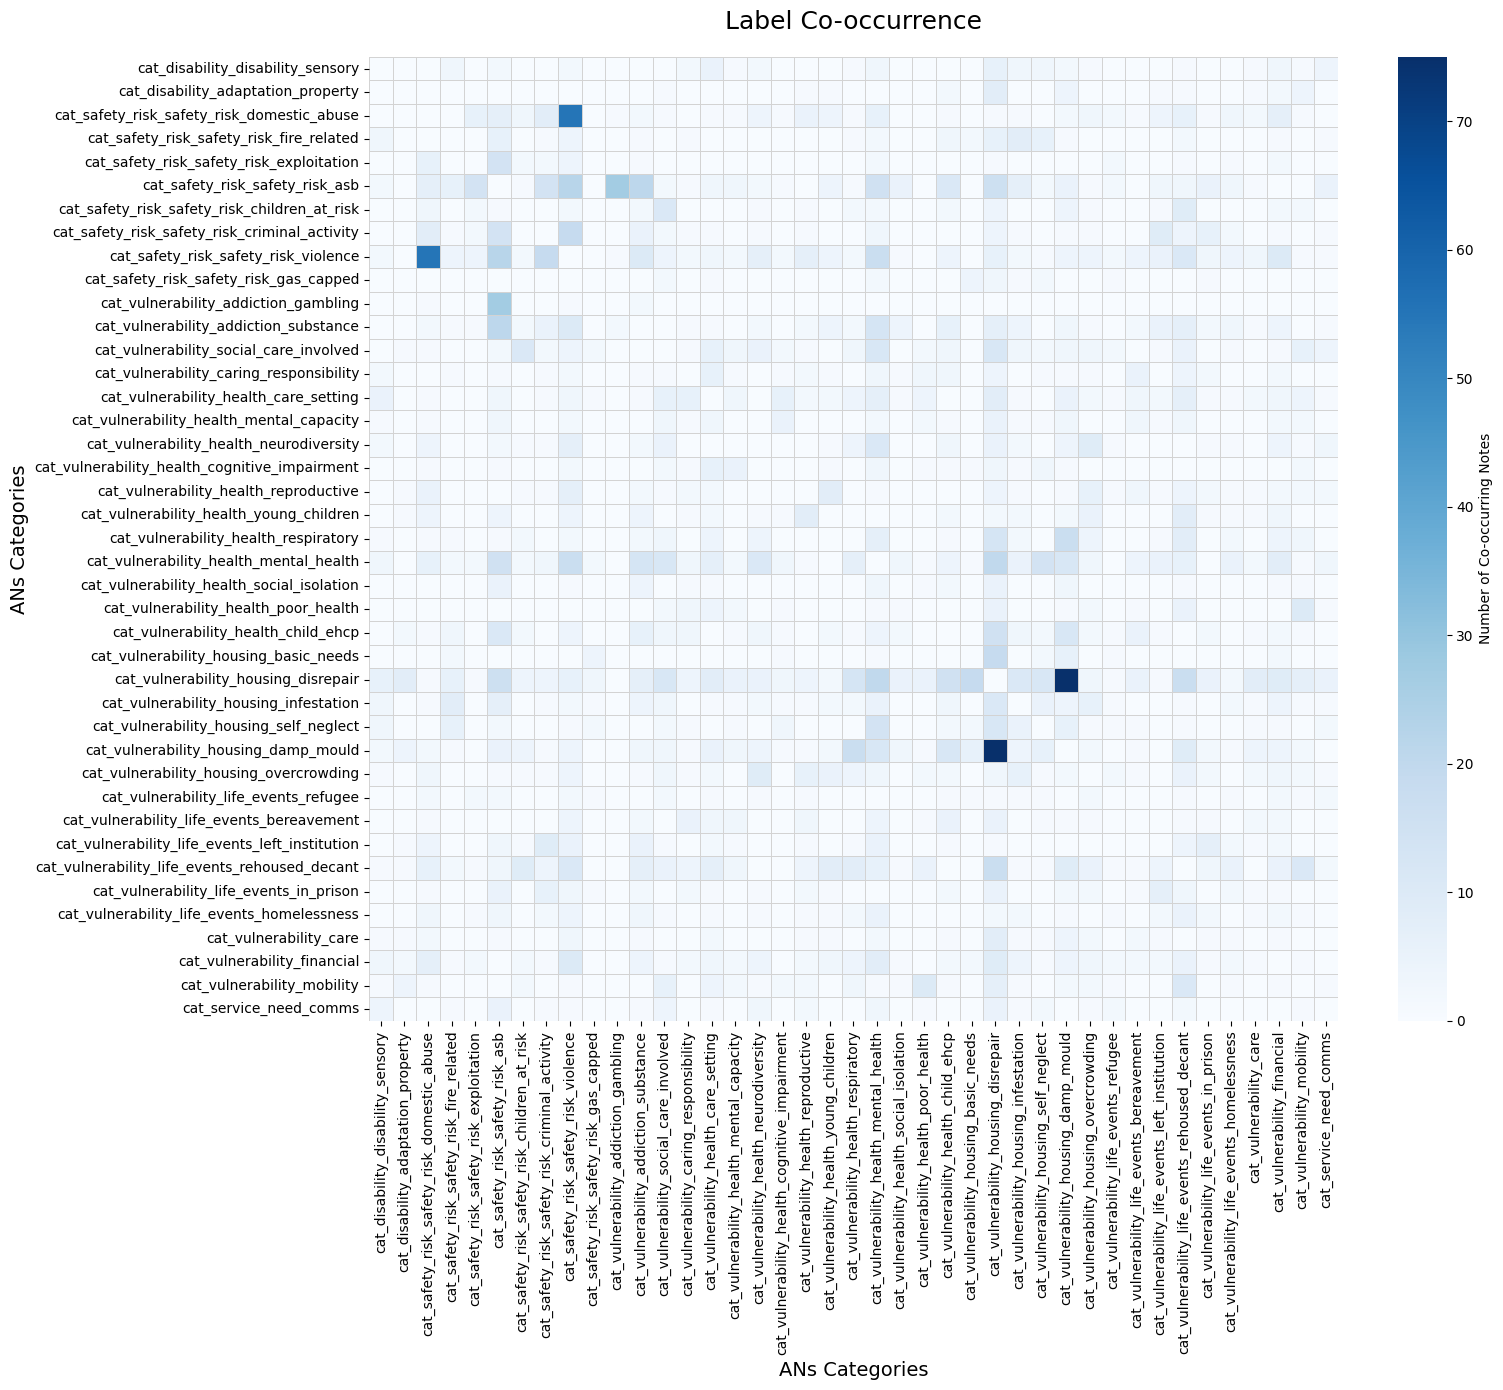

In [ ]:
analyse_class_imbalance(final_sample, taxonomy_v2, log_scale=False)

## PII Redaction

In [ ]:
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

from faker import Faker

In [ ]:
# Set up engines
fake = Faker('en-GB')
Faker.seed(RANDOM_STATE)

analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

tqdm.pandas() # Enable pandas progress_apply (for progress bar)

In [ ]:
# Replace names with fake names
consistent_name_map = {}
def get_consistent_fake_name(text):
    if text not in consistent_name_map:
        consistent_name_map[text] = fake.name()
    return consistent_name_map[text]

operators = {
    "PERSON": OperatorConfig("custom", {"lambda": get_consistent_fake_name})
}

# Track what was found and replaced per note (check to make sure everything has been redacted properly)
def anonymize_with_audit(text):
    # Analyze
    results = analyzer.analyze(text=text, language='en')
    
    # Log what was found
    found_entities = [
        {
            'original': text[r.start:r.end],
            'entity_type': r.entity_type,
            'score': round(r.score, 2),
        }
        for r in results
    ]
    
    # Anonymize
    anonymized = anonymizer.anonymize(
        text=text,
        analyzer_results=results,
        operators=operators
    )
    
    return pd.Series({
        'note_content': anonymized.text,
        'presidio_entities_found': found_entities
    })

scrubbed_df = final_sample.copy()
scrubbed_df[['note_content', 'presidio_entities_found']] = final_sample['note_content'].progress_apply(anonymize_with_audit)
scrubbed_df

100%|██████████| 1500/1500 [00:31<00:00, 46.88it/s]


,note_id,note_content,note_category,cat_disability_disability_sensory,cat_disability_adaptation_property,cat_safety_risk_safety_risk_domestic_abuse,cat_safety_risk_safety_risk_fire_related,cat_safety_risk_safety_risk_exploitation,cat_safety_risk_safety_risk_asb,cat_safety_risk_safety_risk_children_at_risk,...,cat_vulnerability_life_events_left_institution,cat_vulnerability_life_events_rehoused_decant,cat_vulnerability_life_events_in_prison,cat_vulnerability_life_events_homelessness,cat_vulnerability_care,cat_vulnerability_financial,cat_vulnerability_mobility,cat_service_need_comms,unflagged,presidio_entities_found
0,4225661c-e92f-102d-853a-50e621ea5df8,[Category: Tenure management] Applicant attend...,Tenure management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,NaN,[]
1,2a0cd115-cb4f-45a9-9d9f-946e01ceb68c,[Category: estateManagement] Incoming Call - a...,estateManagement,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,NaN,"[{'original': 'Nadine Charlemagne', 'entity_ty..."
2,26fc5b32-489c-c5b4-19b6-7fb76c8e0565,[Category: Tenancy Management] Email sent to a...,Tenancy Management,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,NaN,[]
3,1cb54851-891c-4171-b88a-a5c6877c37de,[Category: estateManagement] Redecorations ema...,estateManagement,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,NaN,"[{'original': 'Florence Hixson - Tenant', 'ent..."
4,14e45fd5-a617-7c2d-c72a-88a669251074,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,NaN,"[{'original': 'Galin Tonev', 'entity_type': 'P..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,93f945a0-a050-472a-b822-1dc8a005e86a,[Category: serviceCharge] Major Work The daugh...,serviceCharge,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,NaN,"[{'original': 'Sarah Bello', 'entity_type': 'P..."
1496,c3e9936d-337b-27eb-ec37-6ccf0aad612f,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,NaN,"[{'original': 'Javid Galiara', 'entity_type': ..."
1497,99236980-85a3-3a64-0f3e-63ad6fbc7efe,[Category: Tenancy Management] <DATE_TIME>: Te...,Tenancy Management,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,NaN,"[{'original': 'today', 'entity_type': 'DATE_TI..."
1498,ed7f9f80-b797-4d92-9281-726906f12f15,[Category: estateManagement] email from tenant...,estateManagement,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,"[{'original': 'rajen.samji@hackney.gov.uk', 'e..."


In [ ]:
# Notes where Presidio found something but wasn't confident
low_confidence = scrubbed_df[
    scrubbed_df['presidio_entities_found'].apply(
        lambda x: any(e['score'] < 0.7 for e in x)
    )
]
pd.set_option('display.max_colwidth', None)
low_confidence[['note_id', 'note_content', 'presidio_entities_found']]

,note_id,note_content,presidio_entities_found
1,2a0cd115-cb4f-45a9-9d9f-946e01ceb68c,"[Category: estateManagement] Incoming Call - anti-social behaviour Urgent: tenant called again to report anti-social behaviour & bullying issues involving pupils from her son's school & Neighbours (Flats 91-92). tenant & children are fearful for their lives, as neighbours (Flat 91-92) have come to her door knocking & kicking. Police attended the property (CAD Number: <PHONE_NUMBER>). Call transfered to HO:Marc Sanderson","[{'original': 'Nadine Charlemagne', 'entity_type': 'PERSON', 'score': 0.85}, {'original': '5537/20032026', 'entity_type': 'PHONE_NUMBER', 'score': 0.75}, {'original': '20032026', 'entity_type': 'US_DRIVER_LICENSE', 'score': 0.4}, {'original': '20032026', 'entity_type': 'US_BANK_NUMBER', 'score': 0.05}]"
5,f35626a6-099a-44ee-be60-935d4413598c,"[Category: estateManagement] Audit home visit Visited tenant at property audit carried out , 3 bed room property occupied by tenant only, he is not interested in downsizing. Next of kin daughter Margret- <DATE_TIME>. Tenants Id passport number :<US_PASSPORT>. No support required from outside agency as tenant has the support of his family ie his children. Repairs raised leak in kitchen and toilet and mould/damp on bathroom. repairs contact centre advised Jobs already raised .","[{'original': '07472205450', 'entity_type': 'DATE_TIME', 'score': 0.85}, {'original': '07472205450', 'entity_type': 'PHONE_NUMBER', 'score': 0.4}, {'original': '126322137', 'entity_type': 'US_PASSPORT', 'score': 0.4}, {'original': '07472205450', 'entity_type': 'US_BANK_NUMBER', 'score': 0.05}, {'original': '126322137', 'entity_type': 'US_BANK_NUMBER', 'score': 0.05}, {'original': '126322137', 'entity_type': 'US_SSN', 'score': 0.05}, {'original': '07472205450', 'entity_type': 'US_DRIVER_LICENSE', 'score': 0.01}, {'original': '126322137', 'entity_type': 'US_DRIVER_LICENSE', 'score': 0.01}]"
6,6b28c390-2e1d-45f8-bb26-3e195c3de587,"[Category: tenureManagement] Succession Approved Secure tenure active as of <DATE_TIME> following the succession approval, due to the death of Joanne Lee.\nAccount set up as per documents received via email on <DATE_TIME> from Celestine Udenze.","[{'original': '01/07/2024', 'entity_type': 'DATE_TIME', 'score': 0.85}, {'original': 'Mrs Barbara Higgins', 'entity_type': 'PERSON', 'score': 0.85}, {'original': '04/11/2024', 'entity_type': 'DATE_TIME', 'score': 0.6}]"
7,726baea7-5824-2d8a-4add-ce2905fb346e,[Category: Tenancy Management] Re: Pre-Notice appointment made for <DATE_TIME>. Tenant at hackney service centre with interpreter. Rent Arrears Payment Agreement made. Agreed payment now increased from <DATE_TIME> to <DATE_TIME> with effect from <DATE_TIME>. TO BE MONITORED.,"[{'original': 'today', 'entity_type': 'DATE_TIME', 'score': 0.85}, {'original': 'Â£80.00/week', 'entity_type': 'DATE_TIME', 'score': 0.85}, {'original': 'Â£100.00/week', 'entity_type': 'DATE_TIME', 'score': 0.85}, {'original': 'today', 'entity_type': 'DATE_TIME', 'score': 0.85}, {'original': '31.05.17', 'entity_type': 'DATE_TIME', 'score': 0.6}]"
17,14860e4a-b832-08e6-a96d-67b84ec9260d,[Category: Service Charges] Callback successful; Callback response logged by <EMAIL_ADDRESS>; Spoke with sub tenant and advised to be reporting any criminal activity to the police via 101. Also informed that concerns have been forwarded onto the recycling team to review the bins.,"[{'original': 'Celestine.Udenze@hackney.gov.uk', 'entity_type': 'EMAIL_ADDRESS', 'score': 1.0}, {'original': 'hackney.gov.uk', 'entity_type': 'URL', 'score': 0.5}]"
...,...,...,...
1492,ec8442b0-f3d8-41fc-a8dc-ae2a4645ac6a,"[Category: tenureManagement] Welfare check I visited the tenant, she is elderly and frail. She might be having surgery soon and would like to move to a newly built property or a re let. She does not want to be added on to the transfer waiting list and does not mind a sheltered property, it must be in woodberry down, manor house or <LOCATION> par

## Highlight spans

In [ ]:
import json

# Construct regexes for ANs & entities 
entity_regex_dict = {
    "Pronoun": r"(?i)\b(he|him|his|she|her|hers|they|them|their)\b", # standard pronouns
    "Descriptive Role": r"(?i)\b(tenant|tenants|leaseholder|leaseholders|resident|residents|child|children|son|daughter|partner|wife|husband|mother|father|caller|applicant)\b" # common housing roles
}
compiled_category_regex = {cat: re.compile(pattern) for cat, pattern in category_regex_dict_v2.items()}
compiled_entity_regex = {ent: re.compile(pattern) for ent, pattern in entity_regex_dict.items()}

clean_label_mapping = dict(zip(taxonomy_v2.cat_label, taxonomy_v2.category))
clean_label_mapping

{'cat_disability_disability_sensory': 'Sensory',
 'cat_disability_adaptation_property': 'Requires adapted property',
 'cat_safety_risk_safety_risk_domestic_abuse': 'Domestic abuse',
 'cat_safety_risk_safety_risk_fire_related': 'Fire-related risks',
 'cat_safety_risk_safety_risk_exploitation': 'Risk of exploitation',
 'cat_safety_risk_safety_risk_asb': 'Anti-Social Behaviour',
 'cat_safety_risk_safety_risk_children_at_risk': 'Children at risk',
 'cat_safety_risk_safety_risk_criminal_activity': 'Criminal activity',
 'cat_safety_risk_safety_risk_violence': 'Violence',
 'cat_safety_risk_safety_risk_gas_capped': 'Gas Capped',
 'cat_vulnerability_addiction_gambling': 'Gambling',
 'cat_vulnerability_addiction_substance': 'Substance misuse',
 'cat_vulnerability_care': 'Care experienced or setting',
 'cat_vulnerability_social_care_involved': 'Social care involvement',
 'cat_vulnerability_caring_responsibility': 'Has caring responsibility',
 'cat_service_need_comms': 'Communication needs',
 'cat

In [ ]:
label_studio_tasks = []

# 3. Loop through cleaned sample
for index, row in scrubbed_df.iterrows():
    note_content = str(row['note_content'])
    note_id = str(row['note_id'])
    
    # Grab the fake names string
    fake_names_display = row.get('fake_names', 'None') 
    
    identified_labels = []
    
    # --- ANs Tags ---
    for cat_key, compiled_regex in compiled_category_regex.items():
        label_name = clean_label_mapping.get(cat_key) 
        
        if label_name:
            for match in compiled_regex.finditer(note_content):
                identified_labels.append({
                    "from_name": "need_labels",
                    "to_name": "text",
                    "type": "labels",
                    "value": {
                        "start": match.start(),
                        "end": match.end(),
                        "text": match.group(),
                        "labels": [label_name]
                    }
                })
        else:
            print(f"Warning: No clean label mapping found for {cat_key}. Skipping...")
                
    # --- Entities (Pronouns/Roles) ---
    for entity_label, compiled_regex in compiled_entity_regex.items():
        for match in compiled_regex.finditer(note_content):
            identified_labels.append({
                "from_name": "entity_labels",
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [entity_label]
                }
            })

    # Construct the final JSON payload (label studio structure - see docs)
    task = {
        "data": {
            "note_content": note_content,
            "id": note_id,
            "fake_names": fake_names_display
        },
        "predictions": [{
            "model_version": "regex_pre_annotated_v2",
            "score": 1.0,
            "result": identified_labels
        }]
    }
        
    label_studio_tasks.append(task)

with open("data/output/label_studio_pre_annotated.json", "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

len(label_studio_tasks)

1500

In [ ]:
scrubbed_df.to_csv('data/output/balanced_sample.csv', index=False)